In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

In [5]:
name = "TOI-1181"
mission = "TESS"
author = "SPOC"
exp_time = 120

In [6]:
tpf_search = lk.search_targetpixelfile(name, mission=mission, author=author, exptime=exp_time)
lc_search = lk.search_lightcurve(name, mission=mission, author=author, exptime=exp_time)

print(tpf_search)
print(lc_search)

SearchResult containing 32 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   229510866      0.0
  1 TESS Sector 25 2020   SPOC     120   229510866      0.0
  2 TESS Sector 26 2020   SPOC     120   229510866      0.0
  3 TESS Sector 40 2021   SPOC     120   229510866      0.0
  4 TESS Sector 41 2021   SPOC     120   229510866      0.0
  5 TESS Sector 47 2021   SPOC     120   229510866      0.0
  6 TESS Sector 60 2022   SPOC     120   229510866      0.0
  7 TESS Sector 59 2022   SPOC     120   229510866      0.0
  8 TESS Sector 58 2022   SPOC     120   229510866      0.0
  9 TESS Sector 56 2022   SPOC     120   229510866      0.0
 10 TESS Sector 55 2022   SPOC     120   229510866      0.0
 11 TESS Sector 54 2022   SPOC     120   229510866      0.0
 12 TESS Sector 57 2022   SPOC     120   229510866      0

In [7]:
print(tpf_search[:5])
print(lc_search[:5])

SearchResult containing 5 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   229510866      0.0
  1 TESS Sector 25 2020   SPOC     120   229510866      0.0
  2 TESS Sector 26 2020   SPOC     120   229510866      0.0
  3 TESS Sector 40 2021   SPOC     120   229510866      0.0
  4 TESS Sector 41 2021   SPOC     120   229510866      0.0
SearchResult containing 5 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 24 2020   SPOC     120   229510866      0.0
  1 TESS Sector 25 2020   SPOC     120   229510866      0.0
  2 TESS Sector 26 2020   SPOC     120   229510866      0.0
  3 TESS Sector 40 2021   SPOC     120   229510866      0.0
  4 TESS Sector 

In [8]:
tpf_downloaded = tpf_search[:5].download_all()
lc_downloaded = lc_search[:5].download_all()

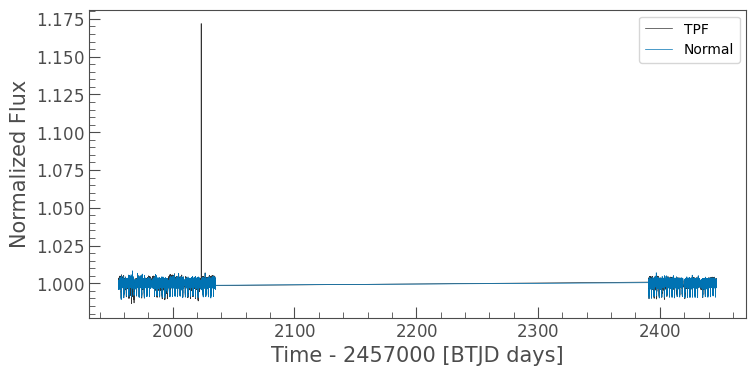

In [12]:
tpf_lightcurves = []
for tpf in tpf_downloaded:
    aperture_mask = tpf.pipeline_mask
    lc = tpf.to_lightcurve(aperture_mask=aperture_mask)
    tpf_lightcurves.append(lc)

tpf_lightcurves = lk.LightCurveCollection(tpf_lightcurves)

stiched_tpf_lc = tpf_lightcurves.stitch()
stiched_normal_lc = lc_downloaded.stitch()

ax = stiched_tpf_lc.plot(label="TPF")
stiched_normal_lc.plot(ax=ax, label="Normal")
plt.legend()
plt.show()




/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_14403/1706677681.py:8: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  ax = folded_tpf_lc.remove_outliers().bin(binsize=10).plot(label="TPF")
/var/folders/c0/vw8qk1r12ls3wbl2nq_z5cx00000gn/T/ipykernel_14403/1706677681.py:9: LightkurveDeprecationWarning: "binsize" was deprecated in version 2.0 and will be removed in a future version. 
        Use time_bin_size instead.
  folded_normal_lc.bin(binsize=10).plot(ax=ax, label="Normal")


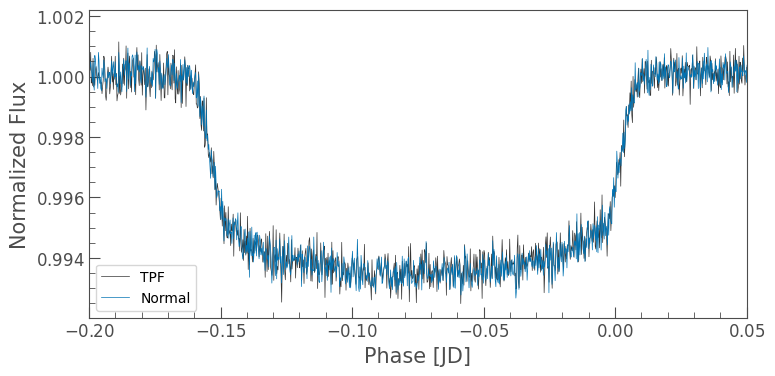

In [20]:
# now phase fold and compare

period = 2.103189

folded_tpf_lc = stiched_tpf_lc.fold(period=period)
folded_normal_lc = stiched_normal_lc.fold(period=period)

ax = folded_tpf_lc.remove_outliers().bin(binsize=10).plot(label="TPF")
folded_normal_lc.bin(binsize=10).plot(ax=ax, label="Normal")
plt.xlim(-0.2,0.05)
plt.legend()
plt.show()